## Use the provided dataset in the drive to solve these exercises

### 1) import pandas and upload the dataset

In [46]:
#1) write your code here:
import pandas as pd
data = pd.read_csv('/content/Automobile_data.csv')

### 2) explore the data and show its columns

In [47]:
#2) write your code here:
data.head()

,index,company,body-style,wheel-base,length,engine-type,num-of-cylinders,horsepower,average-mileage,price
0,0,alfa-romero,convertible,88.6,168.8,dohc,four,111,21,13495.0
1,1,alfa-romero,convertible,88.6,168.8,dohc,four,111,21,16500.0
2,2,alfa-romero,hatchback,94.5,171.2,ohcv,six,154,19,16500.0
3,3,audi,sedan,99.8,176.6,ohc,four,102,24,13950.0
4,4,audi,sedan,99.4,176.6,ohc,five,115,18,17450.0


In [48]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   index             61 non-null     int64  
 1   company           61 non-null     object 
 2   body-style        61 non-null     object 
 3   wheel-base        61 non-null     float64
 4   length            61 non-null     float64
 5   engine-type       61 non-null     object 
 6   num-of-cylinders  61 non-null     object 
 7   horsepower        61 non-null     int64  
 8   average-mileage   61 non-null     int64  
 9   price             58 non-null     float64
dtypes: float64(3), int64(3), object(4)
memory usage: 4.9+ KB


### 3) clean the data from NaNs and fix wrong datatypes (if exists):

In [49]:
#3) write your code here:
data[data.isnull().any(axis = 1)]

,index,company,body-style,wheel-base,length,engine-type,num-of-cylinders,horsepower,average-mileage,price
22,31,isuzu,sedan,94.5,155.9,ohc,four,70,38,NaN
23,32,isuzu,sedan,94.5,155.9,ohc,four,70,38,NaN
47,63,porsche,hatchback,98.4,175.7,dohcv,eight,288,17,NaN


In [50]:
data = data.drop(22).reset_index()

In [51]:
data[data.isnull().any(axis = 1)]

,level_0,index,company,body-style,wheel-base,length,engine-type,num-of-cylinders,horsepower,average-mileage,price
22,23,32,isuzu,sedan,94.5,155.9,ohc,four,70,38,NaN
46,47,63,porsche,hatchback,98.4,175.7,dohcv,eight,288,17,NaN


In [52]:
data[(data['company'] == 'isuzu') | ((data['engine-type'] == 'ohc') & (data['num-of-cylinders'] == 'four') & (data['average-mileage'] == 38))]

,level_0,index,company,body-style,wheel-base,length,engine-type,num-of-cylinders,horsepower,average-mileage,price
14,14,17,chevrolet,hatchback,94.5,155.9,ohc,four,70,38,6295.0
15,15,18,chevrolet,sedan,94.5,158.8,ohc,four,70,38,6575.0
21,21,30,isuzu,sedan,94.3,170.7,ohc,four,78,24,6785.0
22,23,32,isuzu,sedan,94.5,155.9,ohc,four,70,38,NaN


In [53]:
look_like_isuzu = data[(data['company'] == 'isuzu') | ((data['engine-type'] == 'ohc') & (data['num-of-cylinders'] == 'four') & (data['average-mileage'] == 38))]
print(look_like_isuzu['price'].mean())
data.loc[22,'price'] = look_like_isuzu['price'].mean()

6551.666666666667


In [54]:
data[data.isnull().any(axis = 1)]

,level_0,index,company,body-style,wheel-base,length,engine-type,num-of-cylinders,horsepower,average-mileage,price
46,47,63,porsche,hatchback,98.4,175.7,dohcv,eight,288,17,NaN


In [55]:
data[(data['company'] == 'porsche') | (data['horsepower'] > 250)]

,level_0,index,company,body-style,wheel-base,length,engine-type,num-of-cylinders,horsepower,average-mileage,price
25,26,35,jaguar,sedan,102.0,191.7,ohcv,twelve,262,13,36000.0
44,45,61,porsche,hardtop,89.5,168.9,ohcf,six,207,17,34028.0
45,46,62,porsche,convertible,89.5,168.9,ohcf,six,207,17,37028.0
46,47,63,porsche,hatchback,98.4,175.7,dohcv,eight,288,17,NaN


In [56]:
look_like_porsche = data[(data['company'] == 'porsche') | (data['horsepower'] > 250)]
print(look_like_porsche['price'].mean())
data.loc[46,'price'] = look_like_porsche['price'].mean()

35685.333333333336


In [57]:
data[data.isnull().any(axis = 1)]

,level_0,index,company,body-style,wheel-base,length,engine-type,num-of-cylinders,horsepower,average-mileage,price


In [58]:
#there is no column needs to convert its datatype

### 4) Find the most expensive car company name

In [59]:
#4) write your code here:
price_by_company = data.groupby('company')['price'].sum().sort_values(ascending=False)
price_by_company.head()

,price
company,
bmw,163280.000000
mercedes-benz,140160.000000
porsche,106741.333333
jaguar,103800.000000
audi,65570.000000


### 5) Print All Toyota Cars details

In [60]:
#5) write your code here:
data[data['company'] == 'toyota'].describe()

,level_0,index,wheel-base,length,horsepower,average-mileage,price
count,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000
mean,51.000000,70.000000,96.957143,167.571429,75.428571,28.714286,8216.857143
std,2.160247,4.320494,3.326087,10.479299,35.528660,5.089672,3502.409048
min,48.000000,66.000000,95.700000,158.700000,62.000000,19.000000,5348.000000
25%,49.500000,67.500000,95.700000,158.700000,62.000000,27.000000,6413.000000
50%,51.000000,69.000000,95.700000,169.700000,62.000000,31.000000,6918.000000
75%,52.500000,70.500000,95.700000,169.700000,62.000000,31.000000,8338.000000
max,54.000000,79.000000,104.500000,187.800000,156.000000,35.000000,15750.000000


### 6) Count total cars per company

In [61]:
#6) write your code here:
cars_per_company = data.groupby('company')['index'].count()
cars_per_company

,index
company,
alfa-romero,3
audi,4
bmw,6
chevrolet,3
dodge,2
honda,3
isuzu,2
jaguar,3
mazda,5


### 7) Find each company’s Higesht price car

In [62]:
#7) write your code here:
higesht_price_car = data.groupby('company')['price'].max()
higesht_price_car

,price
company,
alfa-romero,16500.0
audi,18920.0
bmw,41315.0
chevrolet,6575.0
dodge,6377.0
honda,12945.0
isuzu,6785.0
jaguar,36000.0
mazda,18344.0


### 8) Find the average mileage of each car making company

In [63]:
#8) write your code here:
mileage_by_company = data.groupby('company')['average-mileage'].mean()
mileage_by_company

,average-mileage
company,
alfa-romero,20.333333
audi,20.000000
bmw,19.000000
chevrolet,41.000000
dodge,31.000000
honda,26.333333
isuzu,31.000000
jaguar,14.333333
mazda,28.000000


### 9) Sort all cars by Price column

In [64]:
#9) write your code here:
data.sort_values(by='price',ascending=False)

,level_0,index,company,body-style,wheel-base,length,engine-type,num-of-cylinders,horsepower,average-mileage,price
34,35,47,mercedes-benz,hardtop,112.0,199.2,ohcv,eight,184,14,45400.000000
11,11,14,bmw,sedan,103.5,193.8,ohc,six,182,16,41315.000000
33,34,46,mercedes-benz,sedan,120.9,208.1,ohcv,eight,184,14,40960.000000
45,46,62,porsche,convertible,89.5,168.9,ohcf,six,207,17,37028.000000
12,12,15,bmw,sedan,110.0,197.0,ohc,six,182,15,36880.000000
25,26,35,jaguar,sedan,102.0,191.7,ohcv,twelve,262,13,36000.000000
46,47,63,porsche,hatchback,98.4,175.7,dohcv,eight,288,17,35685.333333
24,25,34,jaguar,sedan,113.0,199.6,dohc,six,176,15,35550.000000
44,45,61,porsche,hardtop,89.5,168.9,ohcf,six,207,17,34028.000000
23,24,33,jaguar,sedan,113.0,199.6,dohc,six,176,15,32250.000000


### 10) Concatenate two data frames using the following conditions: <br>
GermanCars = {'Company': ['Ford', 'Mercedes', 'BMV', 'Audi'], 'Price': [23845, 171995, 135925 , 71400]}<br>
 japaneseCars = {'Company': ['Toyota', 'Honda', 'Nissan', 'Mitsubishi '], 'Price': [29995, 23600, 61500 , 58900]}<br>

In [65]:
#10) write your code here:
GermanCars = pd.DataFrame({'Company': ['Ford', 'Mercedes', 'BMV', 'Audi'], 'Price': [23845, 171995, 135925 , 71400]})
japaneseCars = pd.DataFrame({'Company': ['Toyota', 'Honda', 'Nissan', 'Mitsubishi '], 'Price': [29995, 23600, 61500 , 58900]})
concatenated_data = pd.concat([GermanCars, japaneseCars])
concatenated_data

,Company,Price
0,Ford,23845
1,Mercedes,171995
2,BMV,135925
3,Audi,71400
0,Toyota,29995
1,Honda,23600
2,Nissan,61500
3,Mitsubishi,58900


### 11) Merge two data frames using the following condition <br>
### Create two data frames using the following two Dicts <br>
### Merge the two data frames, and append the second data frame as a new column to the first data frame. <br>

Car_Price = {'Company': ['Toyota', 'Honda', 'BMV', 'Audi'], 'Price': [23845, 17995, 135925 , 71400]} <br>
car_Horsepower = {'Company': ['Toyota', 'Honda', 'BMV', 'Audi'], 'horsepower': [141, 80, 182 , 160]}

In [66]:
#11) write your code here:
Car_Price = pd.DataFrame({'Company': ['Toyota', 'Honda', 'BMV', 'Audi'], 'Price': [23845, 17995, 135925 , 71400]})
car_Horsepower = pd.DataFrame({'Company': ['Toyota', 'Honda', 'BMV', 'Audi'], 'horsepower': [141, 80, 182 , 160]})
merged_data =Car_Price.merge(car_Horsepower, on='Company', how= 'inner')
merged_data

,Company,Price,horsepower
0,Toyota,23845,141
1,Honda,17995,80
2,BMV,135925,182
3,Audi,71400,160


![image.png](attachment:image.png)

In [67]:
#12) Write a summary about the changes you have done:
"""
Data cleaning --> found 3 rows with Nan values in price column
2 of them was isuzu cars and they are duplicated so i dropped one of them and handle the other one with the mean value of the cars with the same specific of this one
1 of them was porsche car, i handle it with the mean value of the cars with the same specific of this one
*There is no column require to change its datatype*

Analysis :
to find the most expensive car company name i grouped by company column with price
to Print All Toyota Cars details i filtered the data on toyota company and use describe function to extract all information from the numeric columns
to Count total cars per company i grouped by company with a unique identifier like index and use the aggregation function count to count the number of cars in each company
to Find each company’s Higesht price car i grouped by company column with price but use the aggregation function max
to Find the average mileage of each car making company i grouped by company column with average mileage	column
to Sort all cars by Price column i used sort function on price column

combine data :
to Concatenate two data frames first i converted the data from a dictionary to dataframe using pandas then for concatination i used pd.concat() and pass the two dataframes
to Merge two data frames first i converted the data from a dictionary to dataframe using pandas then for merge i used pd.merge() and pass the two dataframes
"""

'\nData cleaning --> found 3 rows with Nan values in price column\n2 of them was isuzu cars and they are duplicated so i dropped one of them and handle the other one with the mean value of the cars with the same specific of this one\n1 of them was porsche car, i handle it with the mean value of the cars with the same specific of this one\n*There is no column require to change its datatype*\n\nAnalysis :\nto find the most expensive car company name i grouped by company column with price\nto Print All Toyota Cars details i filtered the data on toyota company and use describe function to extract all information from the numeric columns\nto Count total cars per company i grouped by company with a unique identifier like index and use the aggregation function count to count the number of cars in each company\nto Find each company’s Higesht price car i grouped by company column with price but use the aggregation function max\nto Find the average mileage of each car making company i grouped by

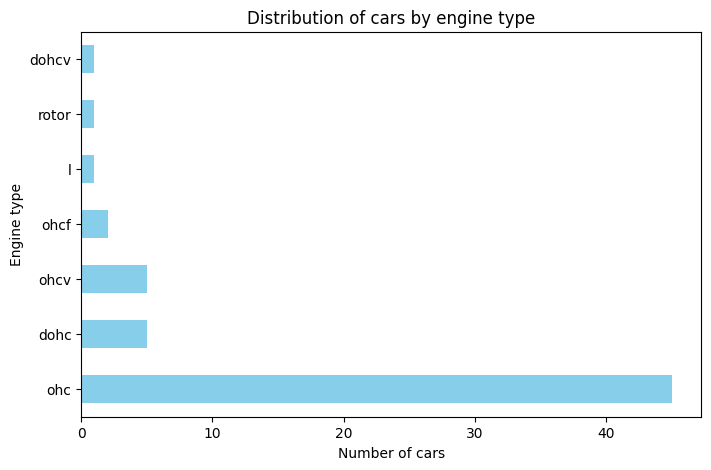

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
plt.figure(figsize=(8,5))
data['engine-type'].value_counts().plot(kind = 'barh',color='skyblue')
plt.title('Distribution of cars by engine type')
plt.xlabel('Number of cars')
plt.ylabel('Engine type')
plt.show()

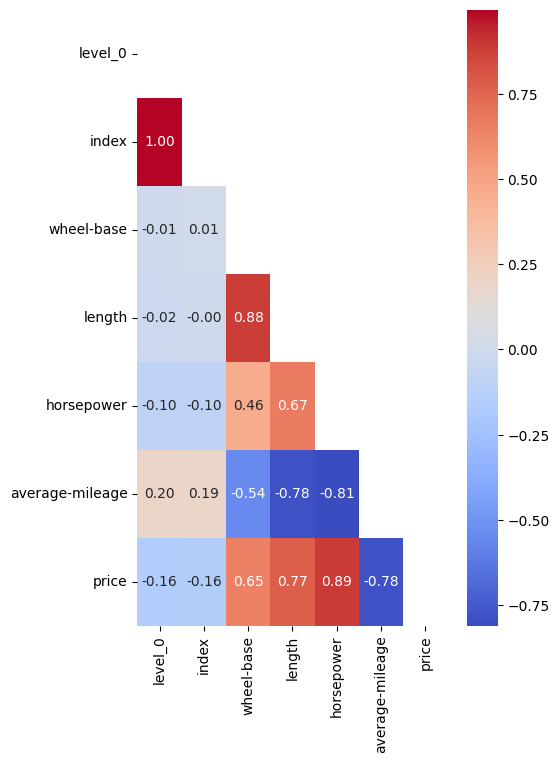

In [69]:
num_data = data.select_dtypes(include='number')
num_data
corr = num_data.corr()
plt.figure(figsize=(5,8))
sns.heatmap(corr,annot=True, cmap='coolwarm', mask=np.triu(corr), fmt = '0.2f')
plt.show()

In [70]:
#machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error,mean_squared_error, r2_score
features = ['horsepower','average-mileage','length','wheel-base']
x = data[features]
y =data['price']

In [71]:
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [72]:
lm = LinearRegression()
lm.fit(x_train, y_train)
print(lm.intercept_)
for feature, coef in zip(features, lm.coef_):
  print(f'{feature}: {coef}')

-58600.475512477344
horsepower: 164.90966922235552
average-mileage: 20.722735649448666
length: -4.220533984885222
wheel-base: 571.0105023150085


In [106]:
y_pred = lm.predict(x_test)
r2 = r2_score(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
print(f'%{r2*100}')
print(rmse)

%88.72485864960328
4664.5445746223395


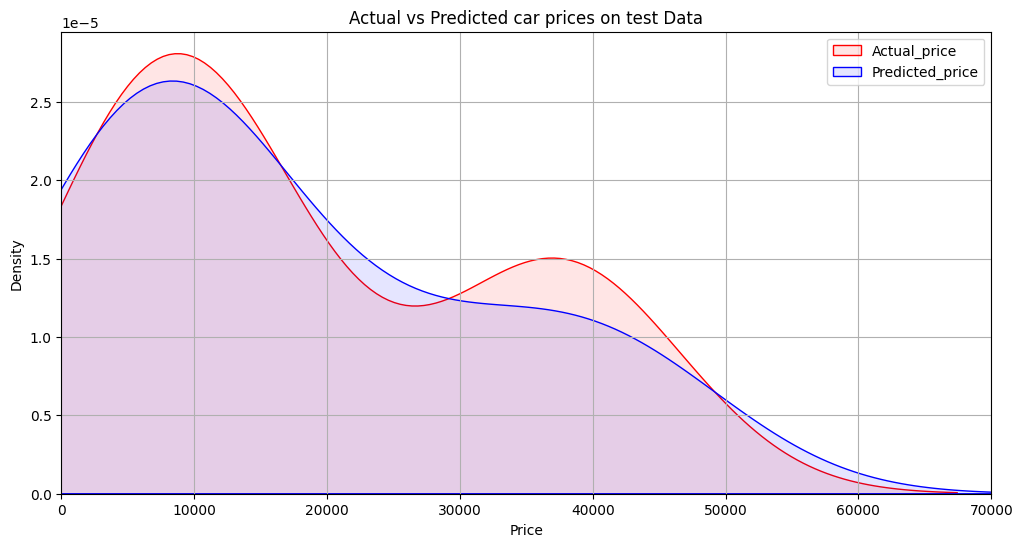

In [78]:
plt.figure(figsize=(12,6))
sns.kdeplot(y_test, color ='r', label = 'Actual_price', fill = True, alpha= 0.1)
sns.kdeplot(y_pred, color ='b', label = 'Predicted_price', fill = True, alpha= 0.1)
plt.title('Actual vs Predicted car prices on test Data')
plt.xlabel('Price')
plt.ylabel('Density')
plt.legend()
plt.grid()
plt.xlim(0,70000)
plt.show()

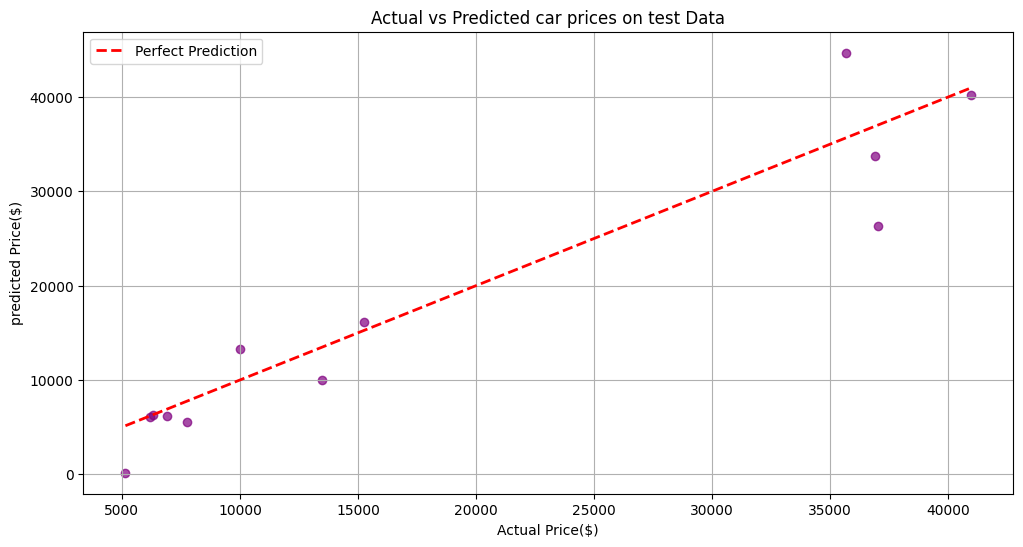

In [84]:
plt.figure(figsize=(12,6))
plt.scatter(y_test, y_pred, alpha=0.7, color='purple')
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], '--r', lw=2, label ='Perfect Prediction')
plt.title('Actual vs Predicted car prices on test Data')
plt.xlabel('Actual Price($)')
plt.ylabel('predicted Price($)')
plt.legend()
plt.grid()
plt.show()

In [92]:
car = {
    'horsepower': [111],
    'average-mileage': [19],
    'length':[168.8],
    'wheel-base':[99.4]
}
single_car = pd.DataFrame(car)
display(single_car)

predicted_price = lm.predict(single_car)
print(f'Predicted price for this car is: ${predicted_price[0]:,.2f}')

,horsepower,average-mileage,length,wheel-base
0,111,19,168.8,99.4


Predicted price for this car is: $16,144.25


In [121]:
real_car = data.iloc[[4]]
features_to_test = real_car[['horsepower','average-mileage','length','wheel-base']]
actual_price = real_car['price'].values[0]

predicted_price = lm.predict(features_to_test)[0]

print(f'Actual Price Is: ${actual_price:,.2f}')
print(f'Predicted Price Is: ${predicted_price:,.2f}')

print(f"Error: ${actual_price - predicted_price}")

Actual Price Is: $17,450.00
Predicted Price Is: $16,750.24
Error: $699.756681835257
